In [33]:
import xarray as xr
import glob
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.dates as mdates
import pandas as pd
import numpy as np
import statsmodels.api as sm
from cmap import Colormap
import seaborn as sns
from scipy import stats
from string import ascii_lowercase, ascii_uppercase
import cftime
from run_webdav_boku import run_client

In [13]:
!ls /sto0/data/Intermediate/Hunga_Tonga_byAles/stocker/data/update_202511


2005-01-01_to_2025-11-30_MLS-Aura_L2GP-H2O_v05_qs_2.5x360_lat_lon.nc
2005-01-01_to_2025-11-30_MLS-Aura_L2GP-O3_v05_qs_2.5x360_lat_lon.nc
2005-01-01_to_2025-11-30_MLS-Aura_L2GP-Temperature_v05_qs_2.5x360_lat_lon.nc


In [2]:
rootpath = Path('/sto0/data/Intermediate/Hunga_Tonga_byAles/')
inpath = rootpath / 'data'
xr.set_options(keep_attrs=True)
plt.rcParams.update({"font.size": 22})

In [3]:
def anomalize(ds, how = 'dayofyear'):
    clim = ds.sel(time = slice('2006','2020')).groupby(f'time.{how}').mean()
    anom = (ds.groupby(f'time.{how}')-clim).load()
    return anom, clim

def rfilter(da):
    weight = xr.DataArray([0.1, 0.25, 0.5, 0.25, 0.1], dims=["y"])

    return da.rolling(pressure = 5, center = True, min_periods = 3).construct(pressure = 'y').dot(weight)

In [4]:
infiles = sorted((rootpath / 'stocker' / 'data' / 'update_202511' ).glob('*.nc'))
infiles = sorted((rootpath / 'stocker' / 'MLSv6' / 'Update_202604' ).glob('*.nc'))
mls_suffix = 'v6'
infiles

[PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/stocker/MLSv6/Update_202604/2004-08-02_to_2026-04-02_MLS-Aura_L2GP-H2O_v06_qs_2.5x360_lat_lon.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/stocker/MLSv6/Update_202604/2004-08-02_to_2026-04-02_MLS-Aura_L2GP-O3_v06_qs_2.5x360_lat_lon.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/stocker/MLSv6/Update_202604/2004-08-02_to_2026-04-02_MLS-Aura_L2GP-Temperature_v06_qs_2.5x360_lat_lon.nc')]

In [5]:
ds  = xr.open_mfdataset(infiles, parallel=True, combine = 'nested')
ds['O3'].attrs['units'] = 'ppmv'
ds['h2o'].attrs['units'] = 'ppmv'
ds['temperature'].attrs['units'] = 'K'
ds

<xarray.Dataset> Size: 376MB
Dimensions:        (latitude_bins: 72, time: 7914, pressure: 55)
Coordinates:
  * latitude_bins  (latitude_bins) float64 576B -88.75 -86.25 ... 86.25 88.75
  * time           (time) datetime64[ns] 63kB 2004-08-02 ... 2026-04-02
  * pressure       (pressure) float32 220B 1e+03 825.4 681.3 ... 2.154e-05 1e-05
Data variables:
    h2o            (latitude_bins, time, pressure) float32 125MB dask.array<chunksize=(72, 7914, 55), meta=np.ndarray>
    O3             (latitude_bins, time, pressure) float32 125MB dask.array<chunksize=(72, 7914, 55), meta=np.ndarray>
    temperature    (latitude_bins, time, pressure) float32 125MB dask.array<chunksize=(72, 7914, 55), meta=np.ndarray>
Attributes:
    title:    Aura MLS v6.01 Level-2 data product
    history:  Postprocessed by WEGC; screened using MLS precision estimates a...

In [6]:
da_t = ds['temperature']
anom_doy, clim_doy = anomalize(ds)
anom_mon, clim_mon = anomalize(ds, how = 'month')

In [7]:
weights = np.cos(np.deg2rad(ds.latitude_bins))
weights.name = "weights"

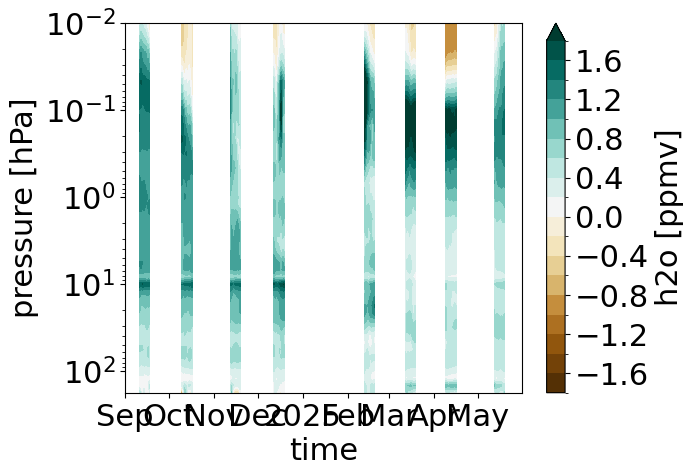

In [8]:
pres_start=200
pres_end = 0.01
s_year = 2024
e_year = 2025
s_month = 10
e_month = 5


time_start = f'{s_year}-{s_month:02d}'
time_end =  f'{e_year}-{e_month:02d}'

temp = anom_mon['h2o'].sel(
    latitude_bins = slice(60,None),
    time = slice(f'{s_year}-{s_month-1:02d}', time_end),
    pressure = slice(pres_start,pres_end),    
).weighted(weights).mean('latitude_bins').plot.contourf(x = 'time', yincrease = False, center =0, robust = True, levels = 21, cmap = 'BrBG')
plt.yscale('log')

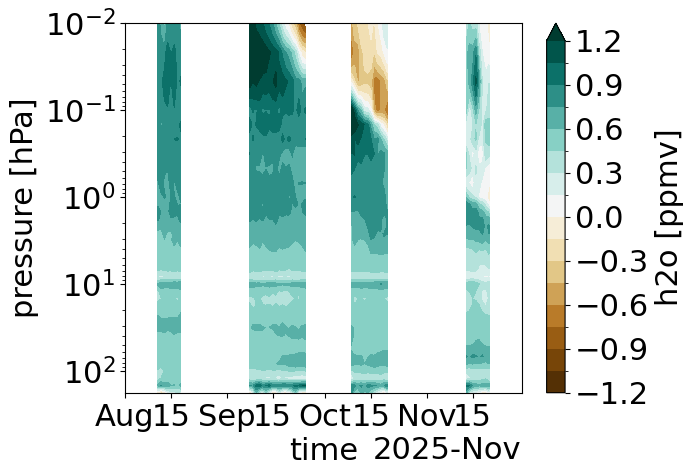

In [80]:
pres_start=200
pres_end = 0.01
s_year = 2025
e_year = 2025
s_month = 9
e_month = 12


time_start = f'{s_year}-{s_month:02d}'
time_end =  f'{e_year}-{e_month:02d}'

temp = anom_mon['h2o'].sel(
    latitude_bins = slice(60,None),
    time = slice(f'{s_year}-{s_month-1:02d}', time_end),
    pressure = slice(pres_start,pres_end),    
).weighted(weights).mean('latitude_bins').plot.contourf(x = 'time', yincrease = False, center =0, robust = True, levels = 21, cmap = 'BrBG')
plt.yscale('log')

In [8]:
clim_mon_new = clim_mon.copy()
clim_mon_new = clim_mon_new.rename({'month': 'dayofyear'})
# https://chatgpt.com/share/68e516e4-8478-8006-8baf-dfdd98ef98fe
clim_mon_new['dayofyear'] = [16, 45, 74, 105, 135, 166, 196, 227, 258, 289, 319, 350]
clim_mon_new = clim_mon_new.interp(dayofyear = np.arange(1,367), kwargs={"fill_value": "extrapolate"})
anom_int = (ds.groupby(f'time.dayofyear')-clim_mon_new).load()

rfilter_bool = False
if rfilter_bool:
    ds_h2o_cor_r = rfilter(ds['h2o'].resample(time = '1M').mean())
    h2o_anom_int_mon = (ds_h2o_cor_r.groupby(f'time.month')-rfilter(clim_mon['h2o'])).load()
else:
    ds_h2o_cor_r = ds['h2o'].resample(time = '1M').mean()
    h2o_anom_int_mon = (ds_h2o_cor_r.groupby(f'time.month')-clim_mon['h2o']).load()

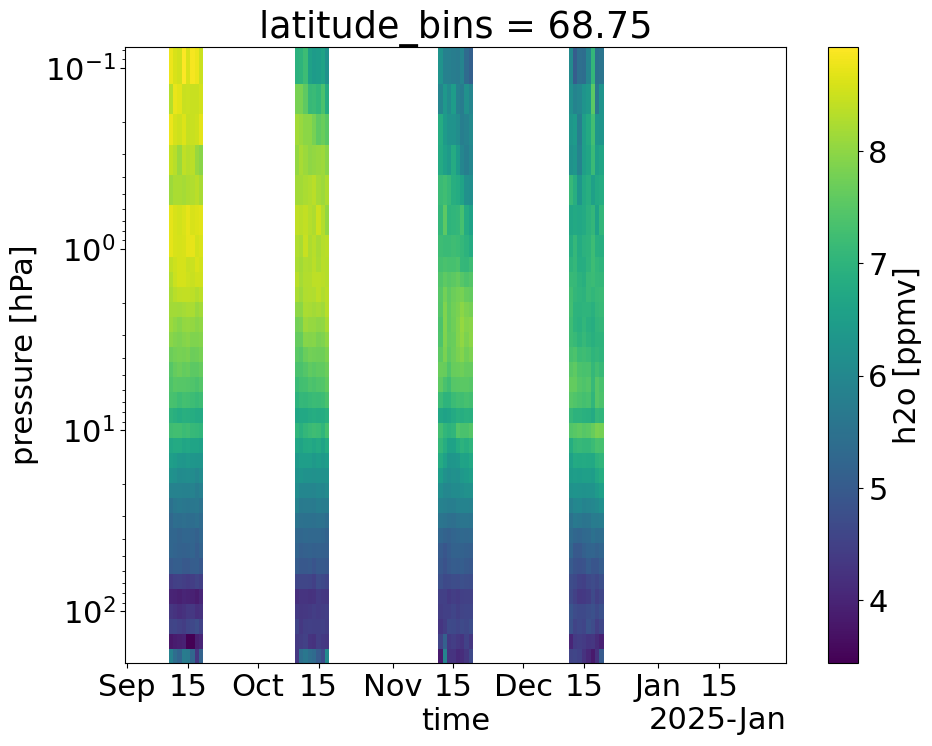

In [82]:
ds['h2o'].sel(time = slice('2024-09-01','2025-01-30'), latitude_bins = 68.75, pressure= slice(200,0.1)).plot(x = 'time', yincrease = False, size = 8)
plt.yscale('log')

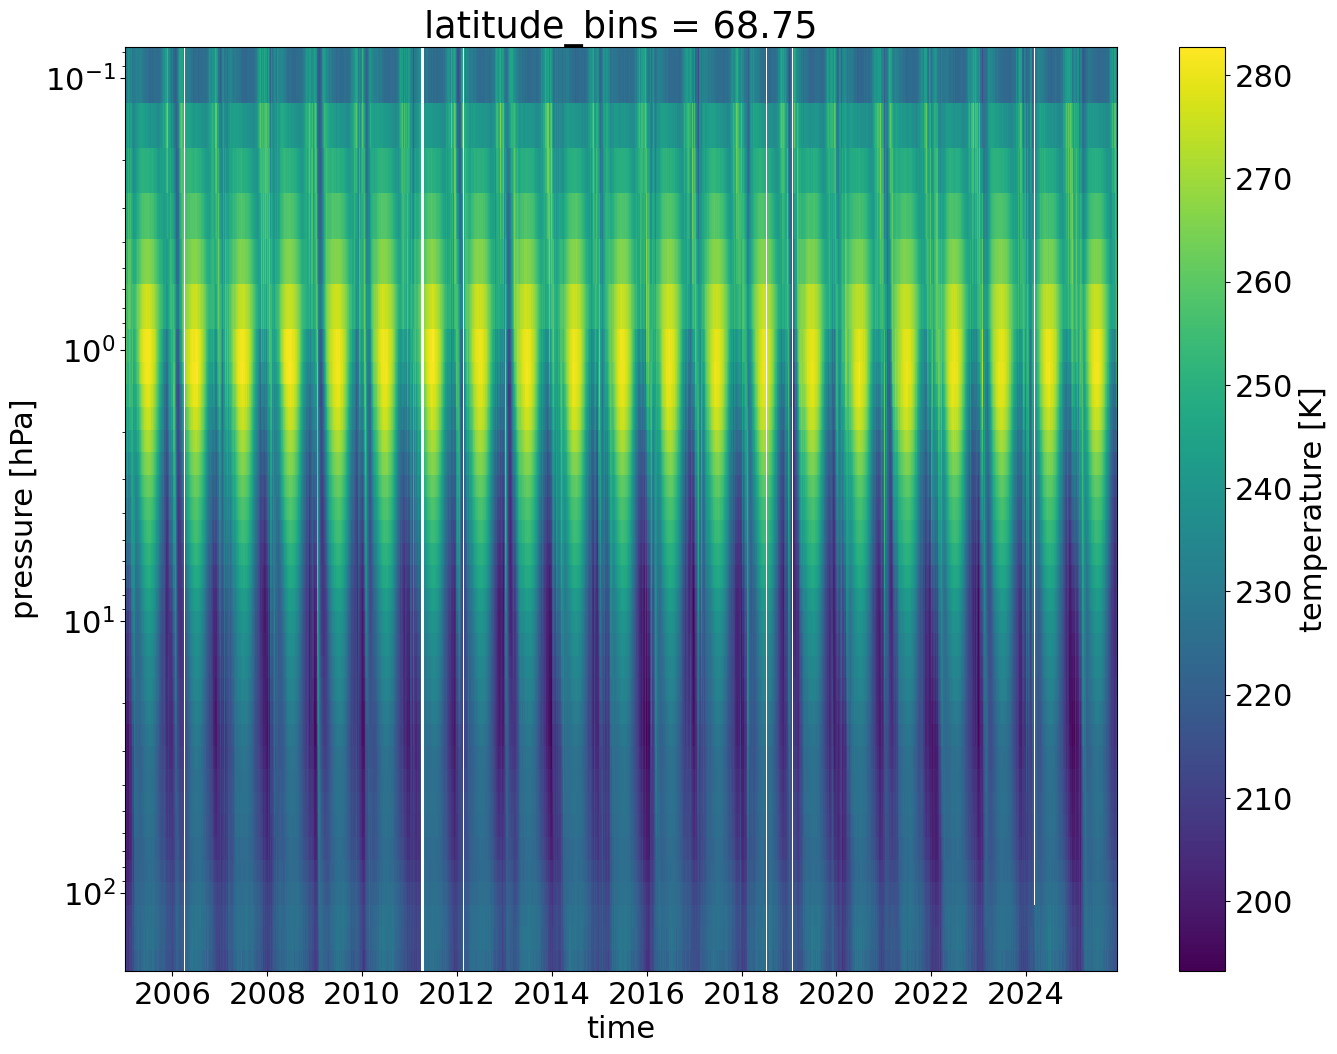

In [83]:
ds['temperature'].sel(latitude_bins = 68.75, pressure= slice(200,0.1)).plot(x = 'time', yincrease = False, size = 12)
plt.yscale('log')

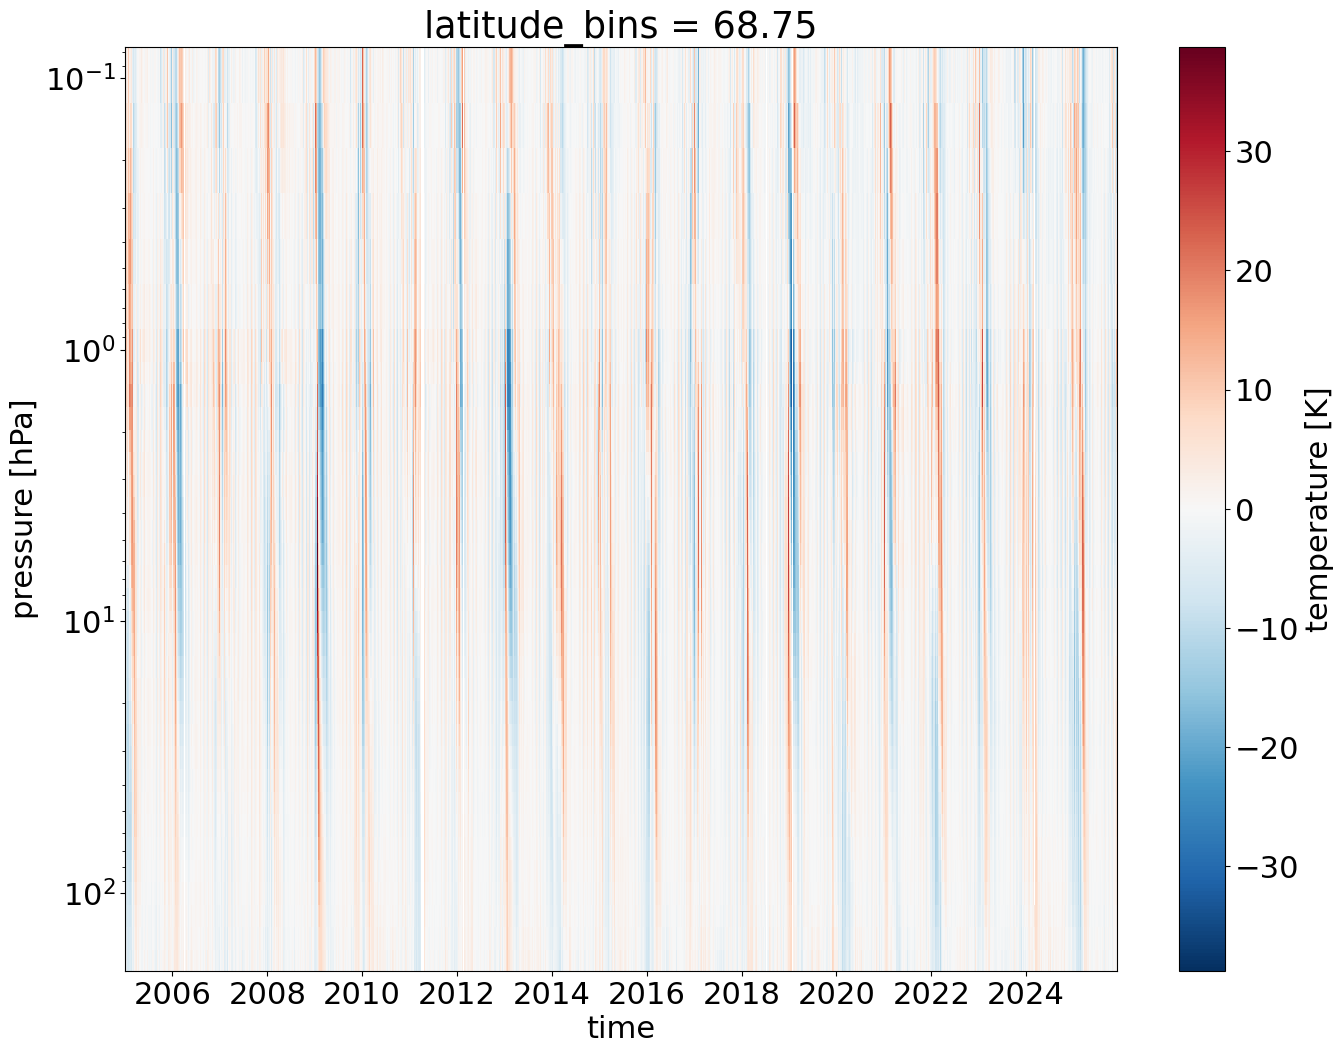

In [84]:
anom_mon['temperature'].sel(latitude_bins = 68.75, pressure= slice(200,0.1)).plot(x = 'time', yincrease = False, size = 12)
plt.yscale('log')

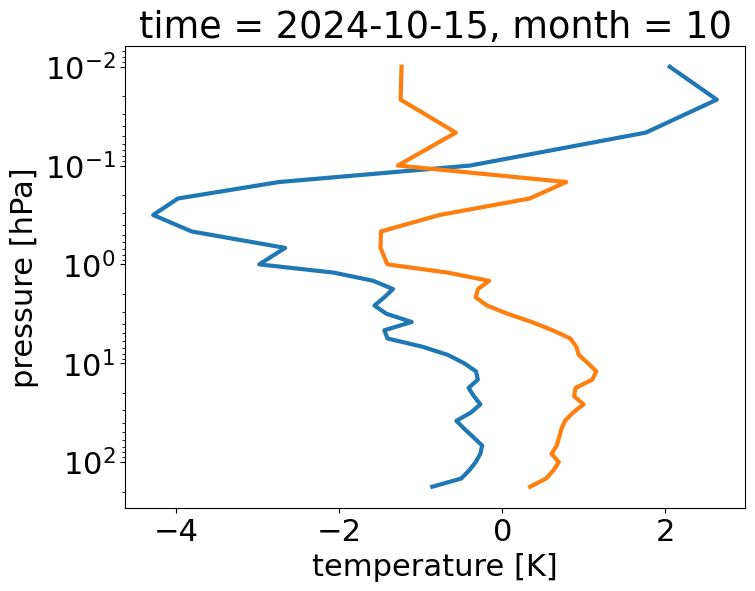

In [14]:
temp = anom_mon['temperature'].sel(
    latitude_bins = slice(60,None),
    pressure = slice(pres_start,pres_end),    
).weighted(weights).mean('latitude_bins')
temp.sel(time = '2025-10-15', method = 'nearest').plot(y = 'pressure', yincrease = False, lw = 3, size = 6)
temp.sel(time = '2024-10-15', method = 'nearest').plot(y = 'pressure', yincrease = False, lw = 3)
plt.yscale('log')

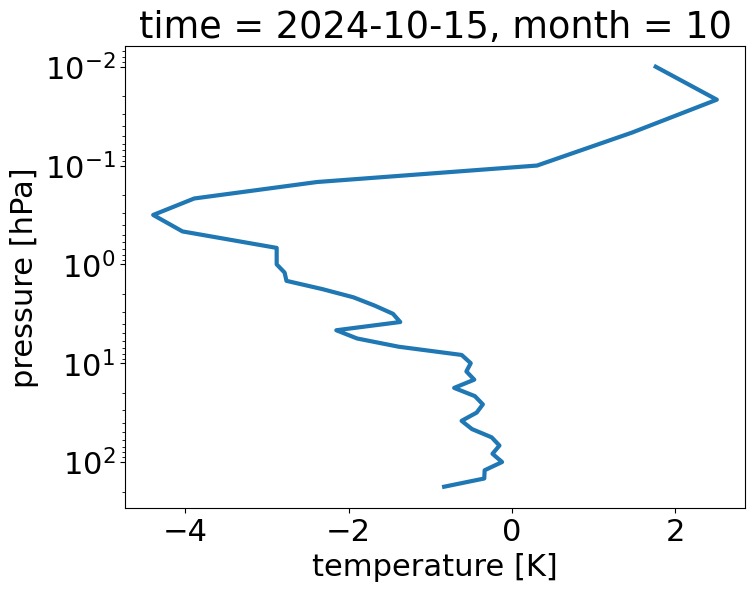

In [46]:
temp = anom_mon['temperature'].sel(
    latitude_bins = slice(60,None),
    pressure = slice(pres_start,pres_end),    
).weighted(weights).mean('latitude_bins')
temp.sel(time = '2025-10-15', method = 'nearest').plot(y = 'pressure', yincrease = False, lw = 3, size = 6)
temp.sel(time = '2024-10-15', method = 'nearest').plot(y = 'pressure', yincrease = False, lw = 3)
plt.yscale('log')

h2o 1.7999999999999992
O3 0.9999999999999996
temperature 18.0
TE+WV+O3_time-evolution_2025-08-2025-11_MLSv6_anom.pdf


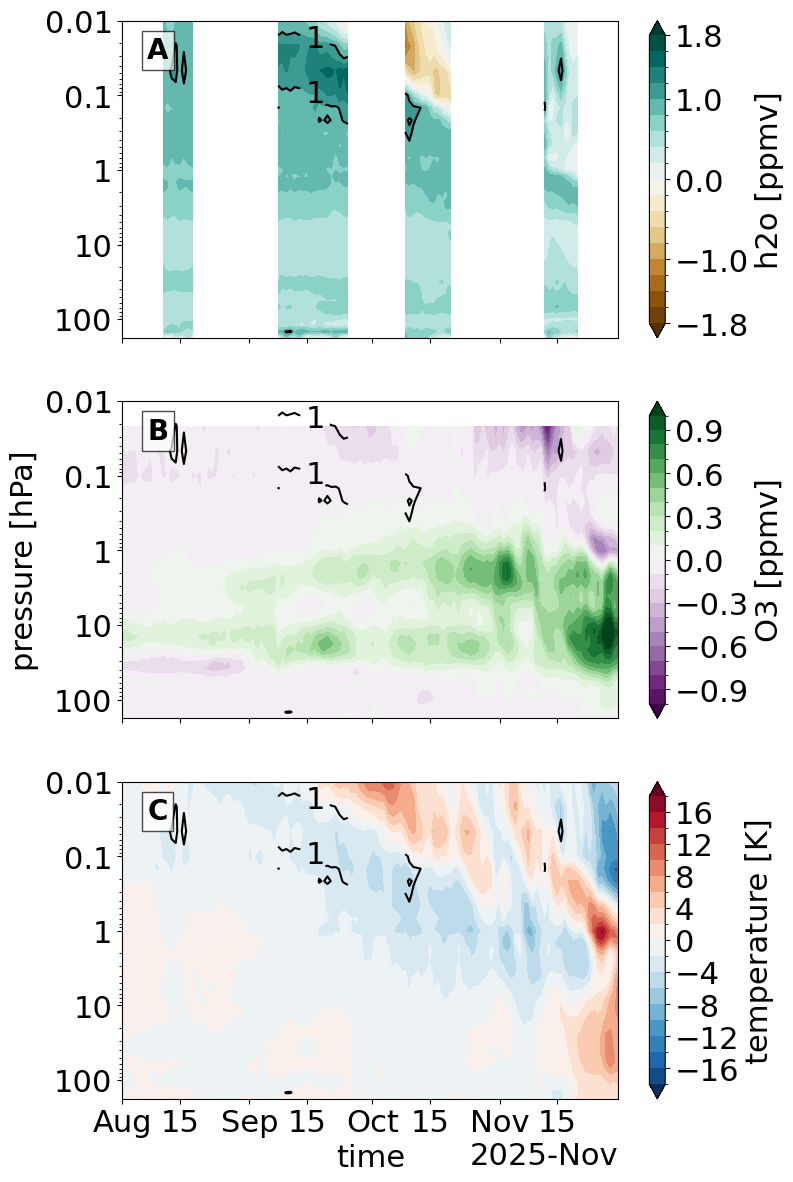

In [31]:
n_rows = 3
f, axes = plt.subplots(n_rows, 1, figsize=(8, 14), sharex =True)
weights = np.cos(np.deg2rad(ds.latitude_bins))
weights.name = "weights"
pres_start=200
pres_end = 0.01
s_year = 2025
e_year = 2025
s_month = 8
e_month = 11
time_start = f'{s_year}-{s_month:02d}'
time_end =  f'{e_year}-{e_month:02d}'

sel_var_ls = ['h2o','O3','temperature',]
cmap_ls = ['BrBG',"PRGn",'RdBu_r',]


temp_dict = {}
for i, (sel_var, ax, cmap) in enumerate(zip(sel_var_ls,axes,cmap_ls)):
   
    if sel_var == 'h2o2':
        temp = h2o_anom_int_mon.sel(
            latitude_bins = slice(60,None),
            time = slice(f'{s_year}-{s_month-1:02d}', time_end),
            pressure = slice(pres_start,pres_end),    
        ).weighted(weights).mean('latitude_bins')
        temp = temp.interpolate_na(dim = 'time')
    else:
        temp = anom_int[sel_var].sel(
            latitude_bins = slice(60,None),
            time = slice(time_start, time_end),
            pressure = slice(pres_start,pres_end),    
        ).weighted(weights).mean('latitude_bins')

    temp_dict[sel_var] = temp

    if sel_var == 'O3':
        p = temp.plot.contourf(
            x = 'time', robust = True, cmap = cmap, 
            yincrease = False, extend = 'both', 
            levels = np.arange(-1,1.1,0.1),
            ax = ax
        )
    elif sel_var == 'h2o':
        p = temp.plot.contourf(
            x = 'time', robust = True, cmap = cmap, 
            yincrease = False, extend = 'both', 
            levels = np.arange(-1.8,2,0.2),
            ax = ax, cbar_kwargs = dict(ticks = [-1.8,-1,0,1,1.8])
        )
    else:
        p = temp.plot.contourf(
            x = 'time', robust = True, cmap = cmap, 
            yincrease = False, extend = 'both', 
            levels = np.arange(-18,20,2),
            center = 0,
            ax = ax
        )
    print(sel_var, p.colorbar.vmax)
    if sel_var in ['h2o','temperature','O3']:
        CS = temp_dict['h2o'].plot.contour(
            x = 'time', 
            yincrease = False, add_colorbar = False, 
            levels = [1],
            colors = ('k'),
            ax = ax
        )
        ax.clabel(CS)
    
    ax.set_yscale('log')
    fmt = mpl.ticker.FormatStrFormatter("%g")
    ax.yaxis.set_major_formatter(fmt)
    
    if i != n_rows-1:
        ax.set_xlabel('')

    if i != 1:
        ax.set_ylabel('')

    label = ascii_uppercase[i]
    ax.text(
            0.05,
            0.95,
            label,
            transform=ax.transAxes,
            fontsize=20,
            fontweight="bold",
            va="top",
            bbox={"alpha": 0.7, "facecolor": "white"},
        )


outfile = f"TE+WV+O3_time-evolution_{time_start}-{time_end}_MLS{mls_suffix}_anom.pdf"
print(outfile)
plt.savefig(outfile, bbox_inches="tight")

In [32]:
from webdav4.fsspec import WebdavFileSystem
from fsspec.implementations.local import LocalFileSystem
from webdav4.client import Client
# https://skshetry.github.io/webdav4/index.html

In [33]:
user = 'ales.kuchar@boku.ac.at'
passw = 'Tt7$Nw8s+(jYBWs<rUI&yx%I'
url = 'https://drive.boku.ac.at/webdav/'

fs = WebdavFileSystem(url, auth=(user, passw))
fs.ls("HT_analysis/figs/strengthening")


[{'name': 'HT_analysis/figs/strengthening/vt45_75-45n_100_2024_merra2.pdf',
  'href': '/webdav/HT_analysis/figs/strengthening/vt45_75-45n_100_2024_merra2.pdf',
  'size': 52299,
  'created': None,
  'modified': datetime.datetime(2025, 9, 26, 9, 1, 59, tzinfo=datetime.timezone.utc),
  'content_language': None,
  'content_type': 'application/pdf',
  'etag': '434afe75546697e2221d2d37cff3098cb5c9cf62',
  'type': 'file',
  'display_name': 'vt45_75-45n_100_2024_merra2.pdf'},
 {'name': 'HT_analysis/figs/strengthening/u60n_10_2024_merra2.pdf',
  'href': '/webdav/HT_analysis/figs/strengthening/u60n_10_2024_merra2.pdf',
  'size': 52306,
  'created': None,
  'modified': datetime.datetime(2025, 9, 26, 9, 2, 20, tzinfo=datetime.timezone.utc),
  'content_language': None,
  'content_type': 'application/pdf',
  'etag': 'a7235e9daf681bb2b2237dbf038312497056fa12',
  'type': 'file',
  'display_name': 'u60n_10_2024_merra2.pdf'},
 {'name': 'HT_analysis/figs/strengthening/stratTCO_time-evolution_north_2324+2

In [34]:
client = Client(url, auth=(user, passw))
client.exists(f"HT_analysis/figs/strengthening/{outfile}")

False

In [35]:
#client.ls("Photos", detail=False)
client.upload_file(outfile, f"HT_analysis/figs/strengthening/{outfile}")

In [36]:
client.exists(f"HT_analysis/figs/strengthening/{outfile}")

True

h2o 1.7999999999999992
O3 0.9999999999999996
temperature 18.0
TE+WV+O3_time-evolution_2024-08-2025-04_MLSv6_anom.pdf


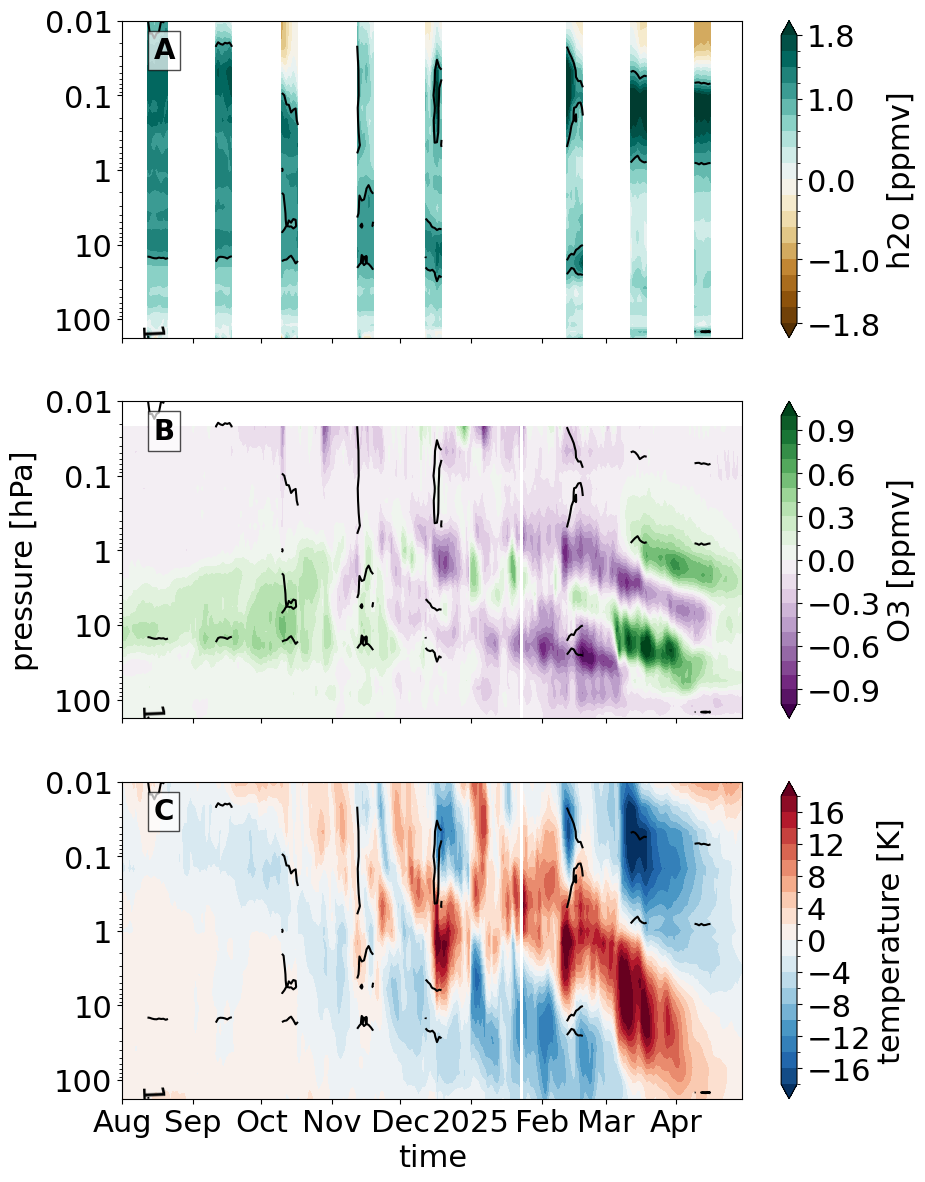

In [46]:
n_rows = 3
f, axes = plt.subplots(n_rows, 1, figsize=(10, 14), sharex =True)
weights = np.cos(np.deg2rad(ds.latitude_bins))
weights.name = "weights"
pres_start=200
pres_end = 0.01
s_year = 2024
e_year = 2025
s_month = 8
e_month = 4
time_start = f'{s_year}-{s_month:02d}'
time_end =  f'{e_year}-{e_month:02d}'

sel_var_ls = ['h2o','O3','temperature',]
cmap_ls = ['BrBG',"PRGn",'RdBu_r',]


temp_dict = {}
for i, (sel_var, ax, cmap) in enumerate(zip(sel_var_ls,axes,cmap_ls)):
   
    if sel_var == 'h2o2':
        temp = h2o_anom_int_mon.sel(
            latitude_bins = slice(60,None),
            time = slice(f'{s_year}-{s_month-1:02d}', time_end),
            pressure = slice(pres_start,pres_end),    
        ).weighted(weights).mean('latitude_bins')
        temp = temp.interpolate_na(dim = 'time')
    else:
        temp = anom_int[sel_var].sel(
            latitude_bins = slice(60,None),
            time = slice(time_start, time_end),
            pressure = slice(pres_start,pres_end),    
        ).weighted(weights).mean('latitude_bins')

    temp_dict[sel_var] = temp

    if sel_var == 'O3':
        p = temp.plot.contourf(
            x = 'time', robust = True, cmap = cmap, 
            yincrease = False, extend = 'both', 
            levels = np.arange(-1,1.1,0.1),
            ax = ax
        )
    elif sel_var == 'h2o':
        p = temp.plot.contourf(
            x = 'time', robust = True, cmap = cmap, 
            yincrease = False, extend = 'both', 
            levels = np.arange(-1.8,2,0.2),
            ax = ax, cbar_kwargs = dict(ticks = [-1.8,-1,0,1,1.8])
        )
    else:
        p = temp.plot.contourf(
            x = 'time', robust = True, cmap = cmap, 
            yincrease = False, extend = 'both', 
            levels = np.arange(-18,20,2),
            center = 0,
            ax = ax
        )
    print(sel_var, p.colorbar.vmax)
    if sel_var in ['h2o','temperature','O3']:
        CS = temp_dict['h2o'].plot.contour(
            x = 'time', 
            yincrease = False, add_colorbar = False, 
            levels = [1],
            colors = ('k'),
            ax = ax
        )
        ax.clabel(CS)
    
    ax.set_yscale('log')
    fmt = mpl.ticker.FormatStrFormatter("%g")
    ax.yaxis.set_major_formatter(fmt)
    
    if i != n_rows-1:
        ax.set_xlabel('')

    if i != 1:
        ax.set_ylabel('')

    label = ascii_uppercase[i]
    ax.text(
            0.05,
            0.95,
            label,
            transform=ax.transAxes,
            fontsize=20,
            fontweight="bold",
            va="top",
            bbox={"alpha": 0.7, "facecolor": "white"},
        )


outfile = f"TE+WV+O3_time-evolution_{time_start}-{time_end}_MLS{mls_suffix}_anom.pdf"
print(outfile)
#plt.savefig(outfile, bbox_inches="tight")

h2o 1.7999999999999992
O3 0.9999999999999996
temperature 18.0
TE+WV+O3_time-evolution_2023-08-2024-04_MLSv6_anom.pdf


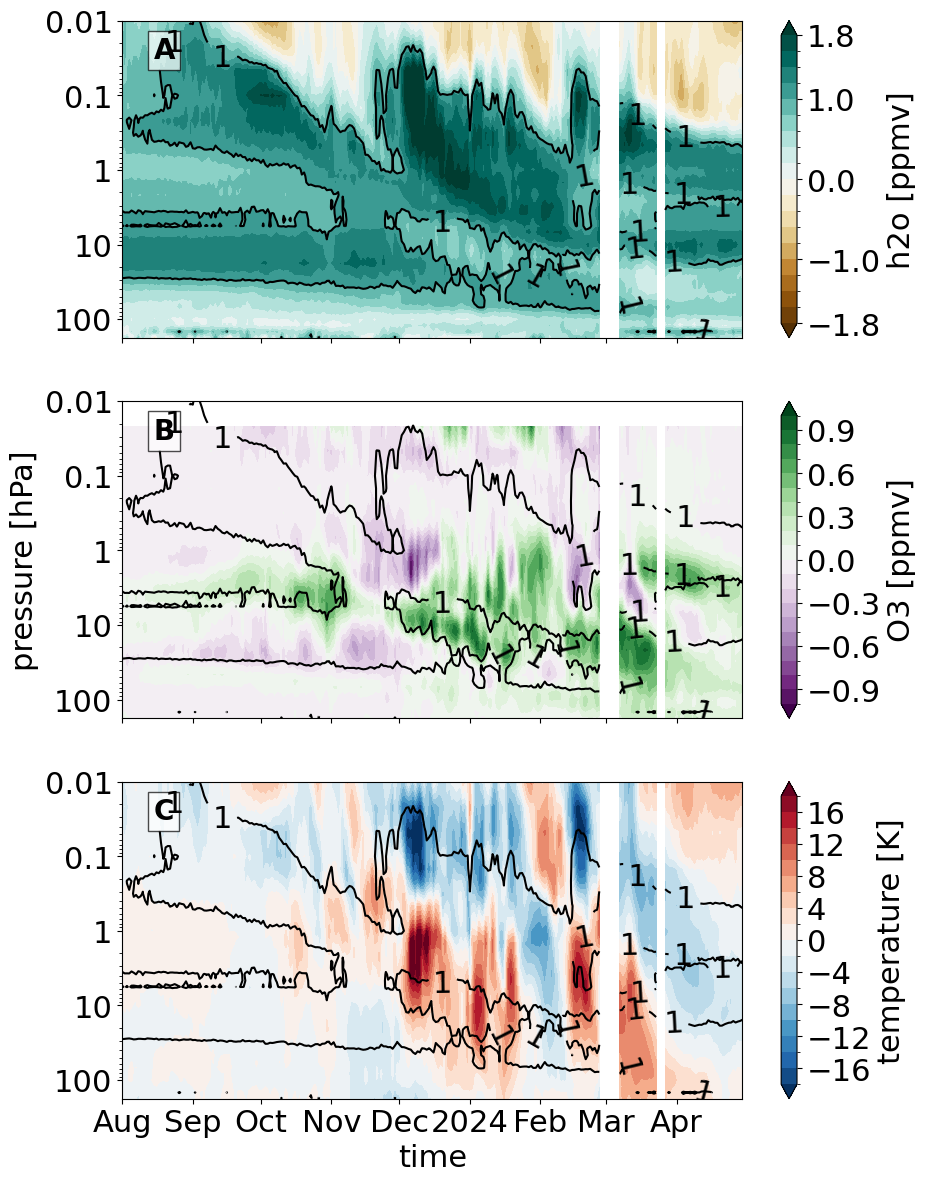

In [38]:
n_rows = 3
f, axes = plt.subplots(n_rows, 1, figsize=(10, 14), sharex =True)
weights = np.cos(np.deg2rad(ds.latitude_bins))
weights.name = "weights"
pres_start=200
pres_end = 0.01
s_year = 2023
e_year = 2024
s_month = 8
e_month = 4
time_start = f'{s_year}-{s_month:02d}'
time_end =  f'{e_year}-{e_month:02d}'

sel_var_ls = ['h2o','O3','temperature',]
cmap_ls = ['BrBG',"PRGn",'RdBu_r',]


temp_dict = {}
for i, (sel_var, ax, cmap) in enumerate(zip(sel_var_ls,axes,cmap_ls)):
   
    if sel_var == 'h2o2':
        temp = h2o_anom_int_mon.sel(
            latitude_bins = slice(60,None),
            time = slice(f'{s_year}-{s_month-1:02d}', time_end),
            pressure = slice(pres_start,pres_end),    
        ).weighted(weights).mean('latitude_bins')
        temp = temp.interpolate_na(dim = 'time')
    else:
        temp = anom_int[sel_var].sel(
            latitude_bins = slice(60,None),
            time = slice(time_start, time_end),
            pressure = slice(pres_start,pres_end),    
        ).weighted(weights).mean('latitude_bins')

    temp_dict[sel_var] = temp

    if sel_var == 'O3':
        p = temp.plot.contourf(
            x = 'time', robust = True, cmap = cmap, 
            yincrease = False, extend = 'both', 
            levels = np.arange(-1,1.1,0.1),
            ax = ax
        )
    elif sel_var == 'h2o':
        p = temp.plot.contourf(
            x = 'time', robust = True, cmap = cmap, 
            yincrease = False, extend = 'both', 
            levels = np.arange(-1.8,2,0.2),
            ax = ax, cbar_kwargs = dict(ticks = [-1.8,-1,0,1,1.8])
        )
    else:
        p = temp.plot.contourf(
            x = 'time', robust = True, cmap = cmap, 
            yincrease = False, extend = 'both', 
            levels = np.arange(-18,20,2),
            center = 0,
            ax = ax
        )
    print(sel_var, p.colorbar.vmax)
    if sel_var in ['h2o','temperature','O3']:
        CS = temp_dict['h2o'].plot.contour(
            x = 'time', 
            yincrease = False, add_colorbar = False, 
            levels = [1],
            colors = ('k'),
            ax = ax
        )
        ax.clabel(CS)
    
    ax.set_yscale('log')
    fmt = mpl.ticker.FormatStrFormatter("%g")
    ax.yaxis.set_major_formatter(fmt)
    
    if i != n_rows-1:
        ax.set_xlabel('')

    if i != 1:
        ax.set_ylabel('')

    label = ascii_uppercase[i]
    ax.text(
            0.05,
            0.95,
            label,
            transform=ax.transAxes,
            fontsize=20,
            fontweight="bold",
            va="top",
            bbox={"alpha": 0.7, "facecolor": "white"},
        )


outfile = f"TE+WV+O3_time-evolution_{time_start}-{time_end}_MLS{mls_suffix}_anom.pdf"
print(outfile)
#plt.savefig(outfile, bbox_inches="tight")

h2o 1.7999999999999992
O3 0.9999999999999996
temperature 18.0
TE+WV+O3_time-evolution_2021-08-2022-04_MLSv6_anom.pdf


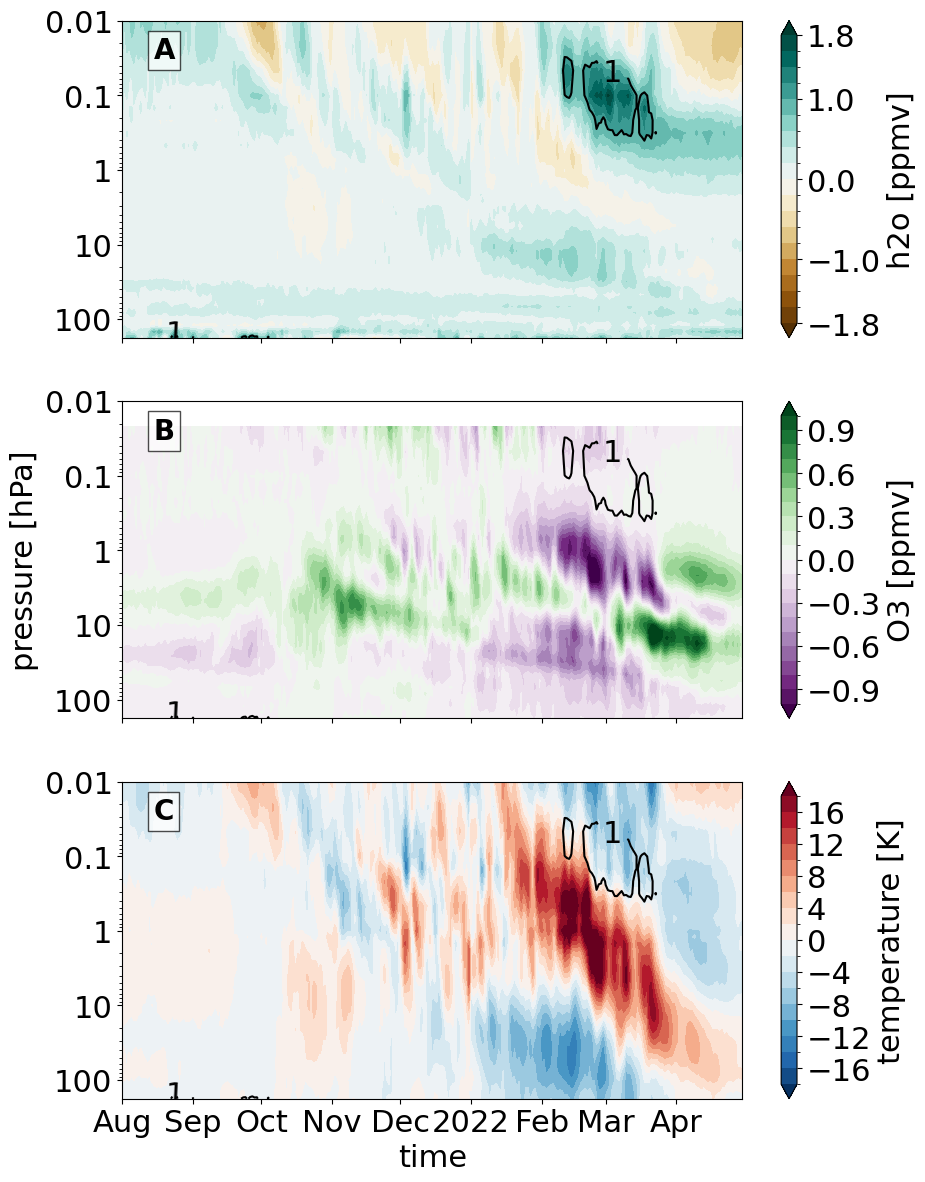

In [158]:
n_rows = 3
f, axes = plt.subplots(n_rows, 1, figsize=(10, 14), sharex =True)
weights = np.cos(np.deg2rad(ds.latitude_bins))
weights.name = "weights"
pres_start=200
pres_end = 0.01
s_year = 2021
e_year = 2022
s_month = 8
e_month = 4
time_start = f'{s_year}-{s_month:02d}'
time_end =  f'{e_year}-{e_month:02d}'

sel_var_ls = ['h2o','O3','temperature',]
cmap_ls = ['BrBG',"PRGn",'RdBu_r',]


temp_dict = {}
for i, (sel_var, ax, cmap) in enumerate(zip(sel_var_ls,axes,cmap_ls)):
   
    if sel_var == 'h2o2':
        temp = h2o_anom_int_mon.sel(
            latitude_bins = slice(60,None),
            time = slice(f'{s_year}-{s_month-1:02d}', time_end),
            pressure = slice(pres_start,pres_end),    
        ).weighted(weights).mean('latitude_bins')
        temp = temp.interpolate_na(dim = 'time')
    else:
        temp = anom_int[sel_var].sel(
            latitude_bins = slice(60,None),
            time = slice(time_start, time_end),
            pressure = slice(pres_start,pres_end),    
        ).weighted(weights).mean('latitude_bins')

    temp_dict[sel_var] = temp

    if sel_var == 'O3':
        p = temp.plot.contourf(
            x = 'time', robust = True, cmap = cmap, 
            yincrease = False, extend = 'both', 
            levels = np.arange(-1,1.1,0.1),
            ax = ax
        )
    elif sel_var == 'h2o':
        p = temp.plot.contourf(
            x = 'time', robust = True, cmap = cmap, 
            yincrease = False, extend = 'both', 
            levels = np.arange(-1.8,2,0.2),
            ax = ax, cbar_kwargs = dict(ticks = [-1.8,-1,0,1,1.8])
        )
    else:
        p = temp.plot.contourf(
            x = 'time', robust = True, cmap = cmap, 
            yincrease = False, extend = 'both', 
            levels = np.arange(-18,20,2),
            center = 0,
            ax = ax
        )
    print(sel_var, p.colorbar.vmax)
    if sel_var in ['h2o','temperature','O3']:
        CS = temp_dict['h2o'].plot.contour(
            x = 'time', 
            yincrease = False, add_colorbar = False, 
            levels = [1],
            colors = ('k'),
            ax = ax
        )
        ax.clabel(CS)
    
    ax.set_yscale('log')
    fmt = mpl.ticker.FormatStrFormatter("%g")
    ax.yaxis.set_major_formatter(fmt)
    
    if i != n_rows-1:
        ax.set_xlabel('')

    if i != 1:
        ax.set_ylabel('')

    label = ascii_uppercase[i]
    ax.text(
            0.05,
            0.95,
            label,
            transform=ax.transAxes,
            fontsize=20,
            fontweight="bold",
            va="top",
            bbox={"alpha": 0.7, "facecolor": "white"},
        )


outfile = f"TE+WV+O3_time-evolution_{time_start}-{time_end}_MLS{mls_suffix}_anom.pdf"
print(outfile)
#plt.savefig(outfile, bbox_inches="tight")

WV_gradient_2023-2024_MLSv6.pdf


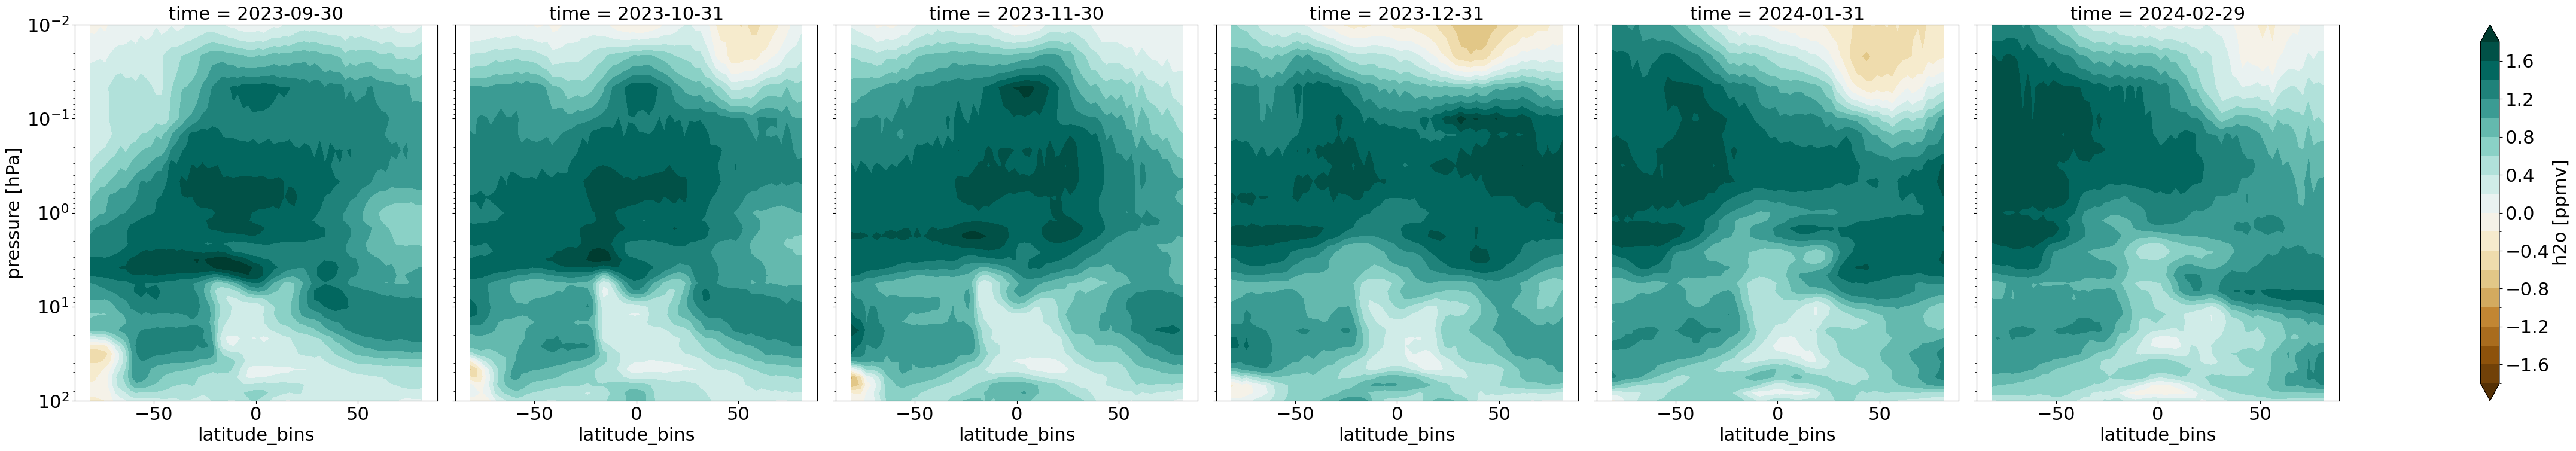

In [45]:
h2o_anom_int_mon.sel(
    time = slice('2023-09','2024-02'),
    pressure = slice(100,0.01),       
).plot.contourf(
    yincrease = False, 
    col = 'time', 
    y = 'pressure', 
    cmap = 'BrBG', 
    levels = np.arange(-1.8,2,0.2),
    size = 8,
    extend = 'both', 
)
plt.yscale('log')
outfile = f"WV_gradient_2023-2024_MLS{mls_suffix}.pdf"
print(outfile)
plt.savefig(outfile, bbox_inches="tight")

In [46]:
client = run_client()
client.exists(f"HT_analysis/figs/strengthening/{outfile}")

True

In [47]:
client.upload_file(outfile, f"HT_analysis/figs/strengthening/{outfile}", overwrite=True)

WV_gradient_2023vs2024_MLSv6.pdf


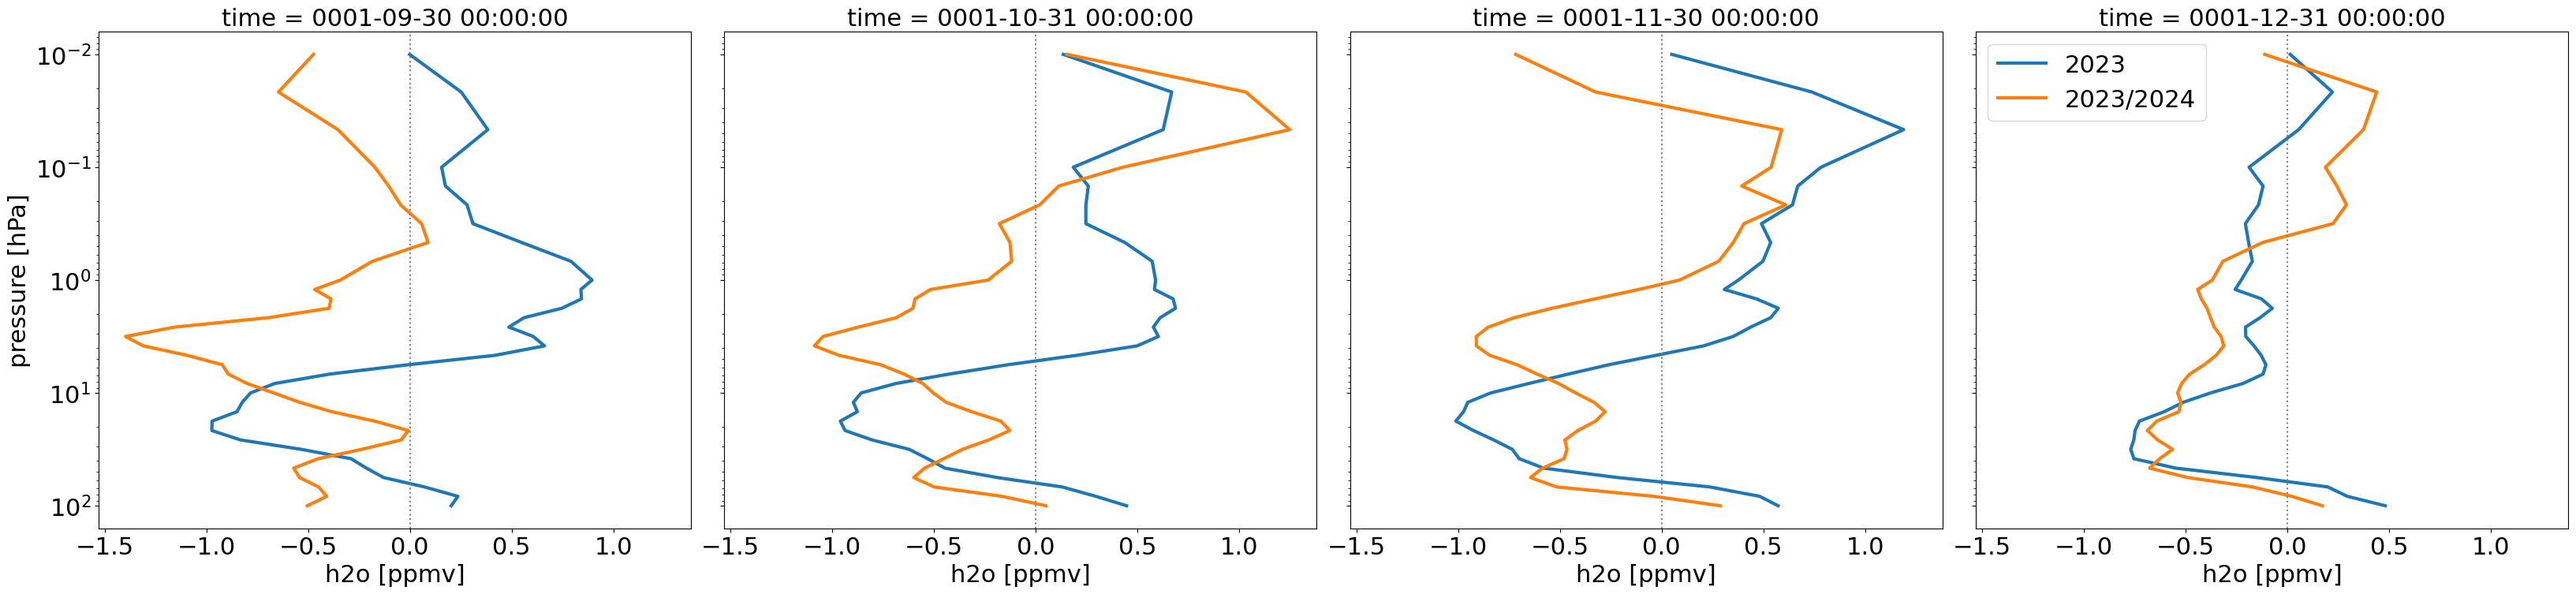

In [42]:
temp_sel = h2o_anom_int_mon.sel(
    time = slice('2023-09','2023-12'),
    pressure = slice(100,0.01),       
)
new_times = [cftime.DatetimeNoLeap(1, date.dt.month, date.dt.day) for date in temp_sel.time]

diff = temp_sel.sel(latitude_bins = slice(-20,20)).weighted(weights).mean('latitude_bins')-temp_sel.sel(latitude_bins = slice(60,90)).weighted(weights).mean('latitude_bins')
diff['time'] = new_times

p = diff.plot(
    yincrease = False, 
    col = 'time', 
    y = 'pressure', 
    #levels = np.arange(-1.8,2,0.2),
    lw = 3,
    size = 8,
    label = '2023'
)
plt.legend()

temp_sel = h2o_anom_int_mon.sel(
    time = slice('2024-09','2024-12'),
    pressure = slice(100,0.01),       
)
diff = temp_sel.sel(latitude_bins = slice(-20,20)).weighted(weights).mean('latitude_bins')-temp_sel.sel(latitude_bins = slice(60,90)).weighted(weights).mean('latitude_bins')
diff['time'] = new_times

p.data = diff
kwargs = dict(lw = 3, label = '2024')
p.map_dataarray_line(xr.plot.line, x = None, y='pressure', hue = 'time', **kwargs)
kwargs = dict(x=0, ls = 'dotted', c = 'gray')
plt.legend()

"""
temp_sel = h2o_anom_int_mon.sel(
    time = slice('2025-09','2025-12'),
    pressure = slice(100,0.01),       
)
diff = temp_sel.sel(latitude_bins = slice(-20,20)).weighted(weights).mean('latitude_bins')-temp_sel.sel(latitude_bins = slice(60,90)).weighted(weights).mean('latitude_bins')
diff['time'] = new_times

p.data = diff
kwargs = dict(lw = 3, label = '2024/2025')
p.map_dataarray_line(xr.plot.line, x = None, y='pressure', hue = 'time', **kwargs)
kwargs = dict(x=0, ls = 'dotted', c = 'gray')
"""
plt.legend()

p.map(plt.axvline, **kwargs)
plt.yscale('log')
outfile = f"WV_gradient_2023vs2024vs2025_MLS{mls_suffix}.pdf"
outfile = f"WV_gradient_2023vs2024_MLS{mls_suffix}.pdf"
print(outfile)
plt.savefig(outfile, bbox_inches="tight")

In [154]:
client = run_client()
client.exists(f"HT_analysis/figs/strengthening/{outfile}")

False

In [155]:
client.upload_file(outfile, f"HT_analysis/figs/strengthening/{outfile}", overwrite=True)

WV_gradient_2024-2025_MLSv6.pdf


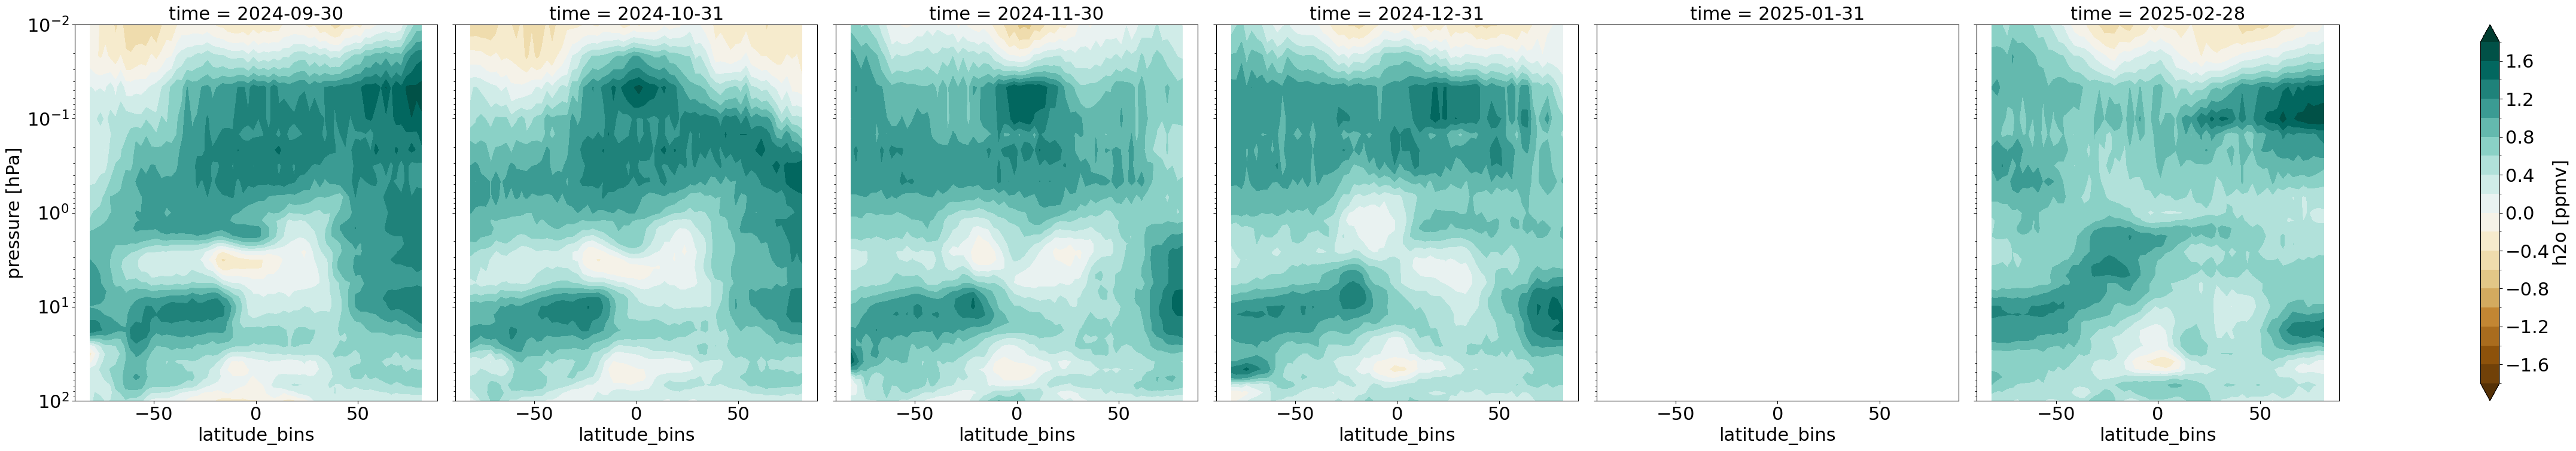

In [48]:
h2o_anom_int_mon.sel(
    time = slice('2024-09','2025-02'),
    pressure = slice(100,0.01),       
).plot.contourf(
    yincrease = False, 
    col = 'time', 
    y = 'pressure', 
    cmap = 'BrBG', 
    levels = np.arange(-1.8,2,0.2),
    size = 8,
    extend = 'both', 
)
plt.yscale('log')
outfile = f"WV_gradient_2024-2025_MLS{mls_suffix}.pdf"
print(outfile)
plt.savefig(outfile, bbox_inches="tight")

In [49]:
client = run_client()
client.exists(f"HT_analysis/figs/strengthening/{outfile}")

True

In [50]:
client.upload_file(outfile, f"HT_analysis/figs/strengthening/{outfile}", overwrite=True)

Text(0.5, 1.0, '202409/2025-02')

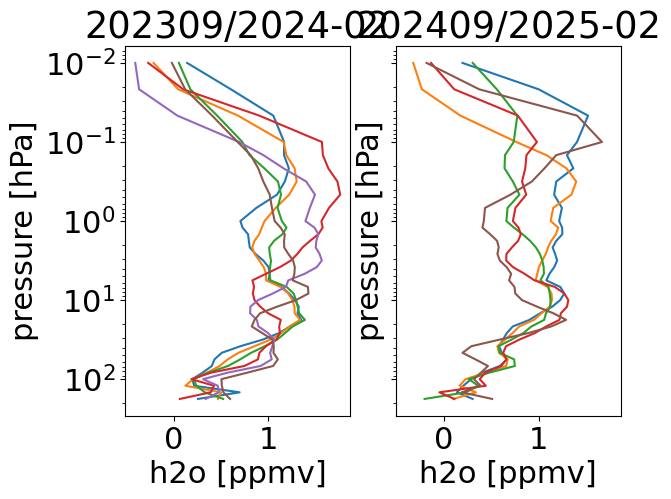

In [12]:
pres_start=200
pres_end = 0.01

s_year = 2023
s_month = 9
e_month = 2
time_end =  f'{s_year+1}-{e_month:02d}'
temp = h2o_anom_int_mon.sel(
    latitude_bins = slice(60,None),
    time = slice(f'{s_year}-{s_month:02d}', time_end),
    pressure = slice(pres_start,pres_end),    
).weighted(weights).mean('latitude_bins')

fig, axes = plt.subplots(ncols=2, sharex=True, sharey=True)
ax = axes[0]
p = temp.plot(hue = 'time', ax = ax, y = 'pressure', yincrease = False, add_legend = False)
ax.set_yscale('log')
ax.set_title(f'{s_year}{s_month:02d}/{time_end}')


s_year = 2024
time_end =  f'{s_year+1}-{e_month:02d}'
temp = h2o_anom_int_mon.sel(
    latitude_bins = slice(60,None),
    time = slice(f'{s_year}-{s_month:02d}', time_end),
    pressure = slice(pres_start,pres_end),    
).weighted(weights).mean('latitude_bins')
ax = axes[1]
temp.plot(ax = ax, hue = 'time', y = 'pressure', yincrease = False, add_legend = False)
ax.set_yscale('log')
ax.set_title(f'{s_year}{s_month:02d}/{time_end}')

Text(0.5, 1.0, '202409/2025-02')

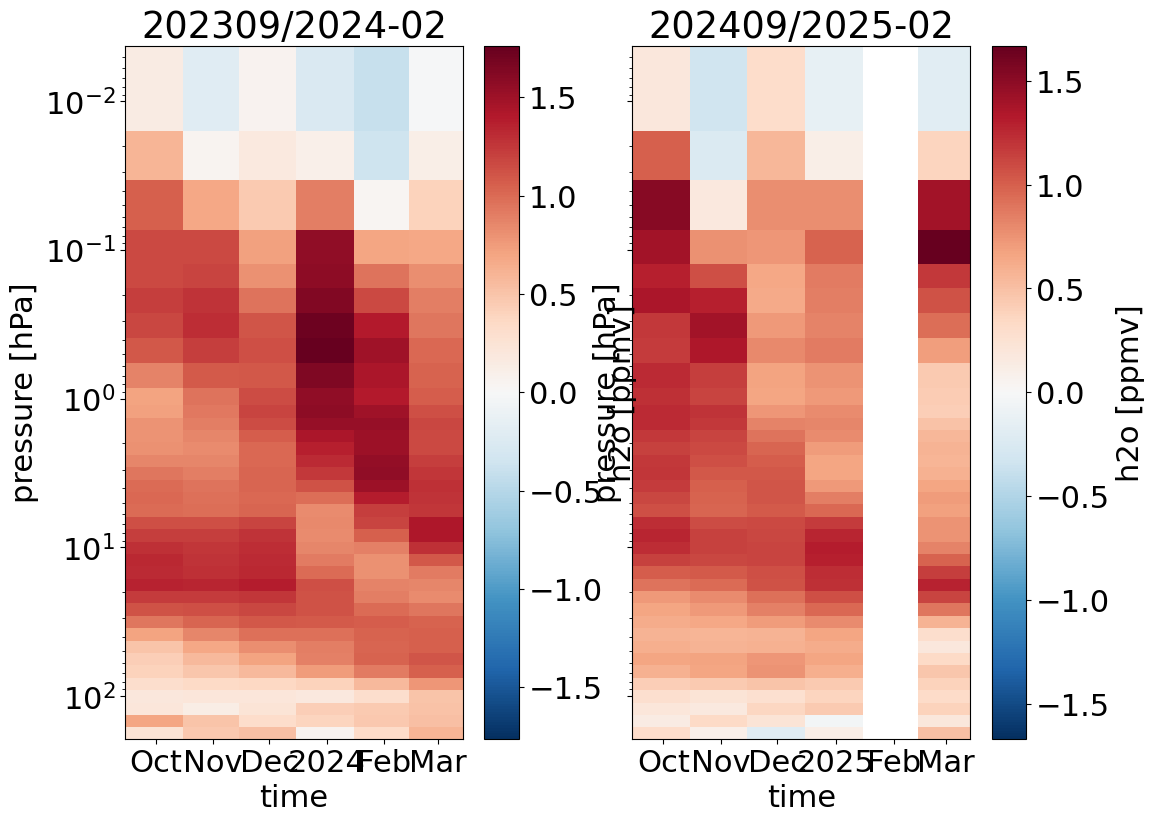

In [16]:
pres_start=200
pres_end = 0.01

s_year = 2023
s_month = 9
e_month = 2
time_end =  f'{s_year+1}-{e_month:02d}'
temp = h2o_anom_int_mon.sel(
    latitude_bins = slice(60,None),
    time = slice(f'{s_year}-{s_month:02d}', time_end),
    pressure = slice(pres_start,pres_end),    
).weighted(weights).mean('latitude_bins')

fig, axes = plt.subplots(ncols=2, sharex=False, sharey=True, figsize = (12,9))
ax = axes[0]
p = temp.plot(x = 'time', ax = ax, y = 'pressure', yincrease = False, )
ax.set_yscale('log')
ax.set_title(f'{s_year}{s_month:02d}/{time_end}')


s_year = 2024
time_end =  f'{s_year+1}-{e_month:02d}'
temp = h2o_anom_int_mon.sel(
    latitude_bins = slice(60,None),
    time = slice(f'{s_year}-{s_month:02d}', time_end),
    pressure = slice(pres_start,pres_end),    
).weighted(weights).mean('latitude_bins')
ax = axes[1]
temp.plot(ax = ax, x = 'time', y = 'pressure', yincrease = False, )
ax.set_yscale('log')
ax.set_title(f'{s_year}{s_month:02d}/{time_end}')

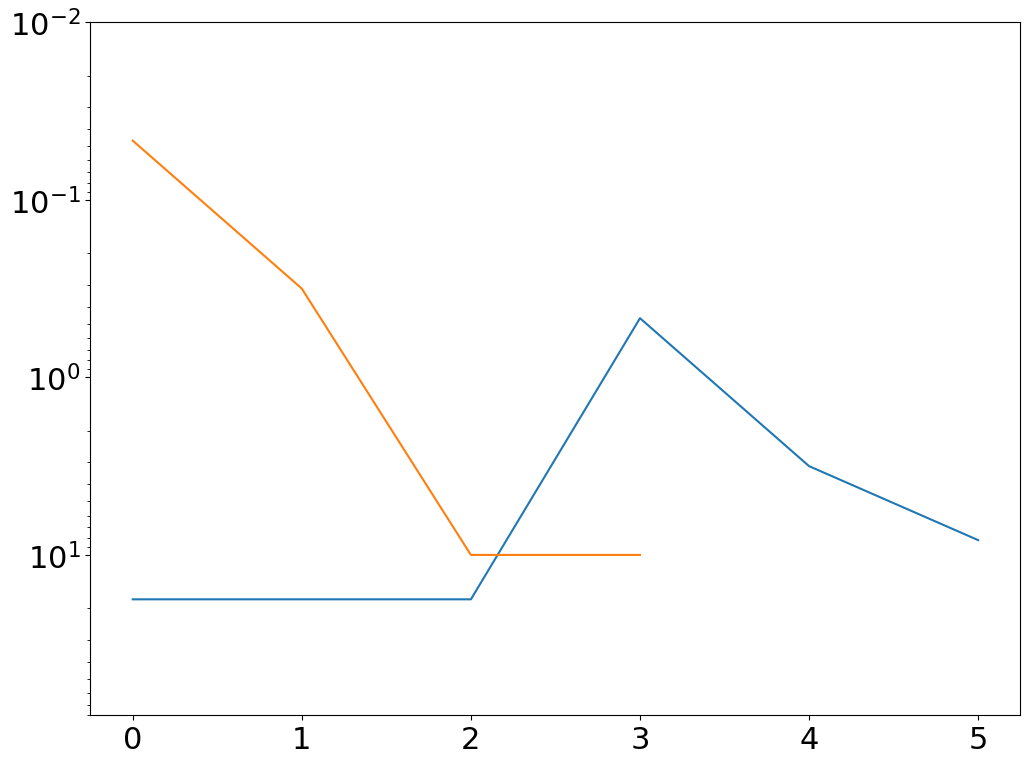

In [30]:
pres_start=200
pres_end = 0.01

s_year = 2023
s_month = 9
e_month = 2
time_end =  f'{s_year+1}-{e_month:02d}'
temp = h2o_anom_int_mon.sel(
    latitude_bins = slice(60,None),
    time = slice(f'{s_year}-{s_month:02d}', time_end),
    pressure = slice(pres_start,pres_end),    
).weighted(weights).mean('latitude_bins')
#p = temp.idxmax('pressure').plot(yincrease = False)
ax = p[0].axes

fig, ax = plt.subplots(ncols=1, figsize = (12,9))
ax.plot(np.arange(6), temp.idxmax('pressure').values)

s_year = 2024
time_end =  f'{s_year+1}-{e_month:02d}'
temp = h2o_anom_int_mon.sel(
    latitude_bins = slice(60,None),
    time = slice(f'{s_year}-{s_month:02d}', time_end),
    pressure = slice(pres_start,pres_end),    
).weighted(weights).mean('latitude_bins')
ax.plot(np.arange(6), temp.idxmax('pressure').values)
ax.set_ylim(80,0.01)
ax.set_yscale('log')
#ax.set_title(f'{s_year}{s_month:02d}/{time_end}')


h2o 1.7999999999999992
O3 0.9999999999999996
temperature 18.0
TE+WV+O3_time-evolution_2025-08-2026-04_MLSv6_anom.pdf


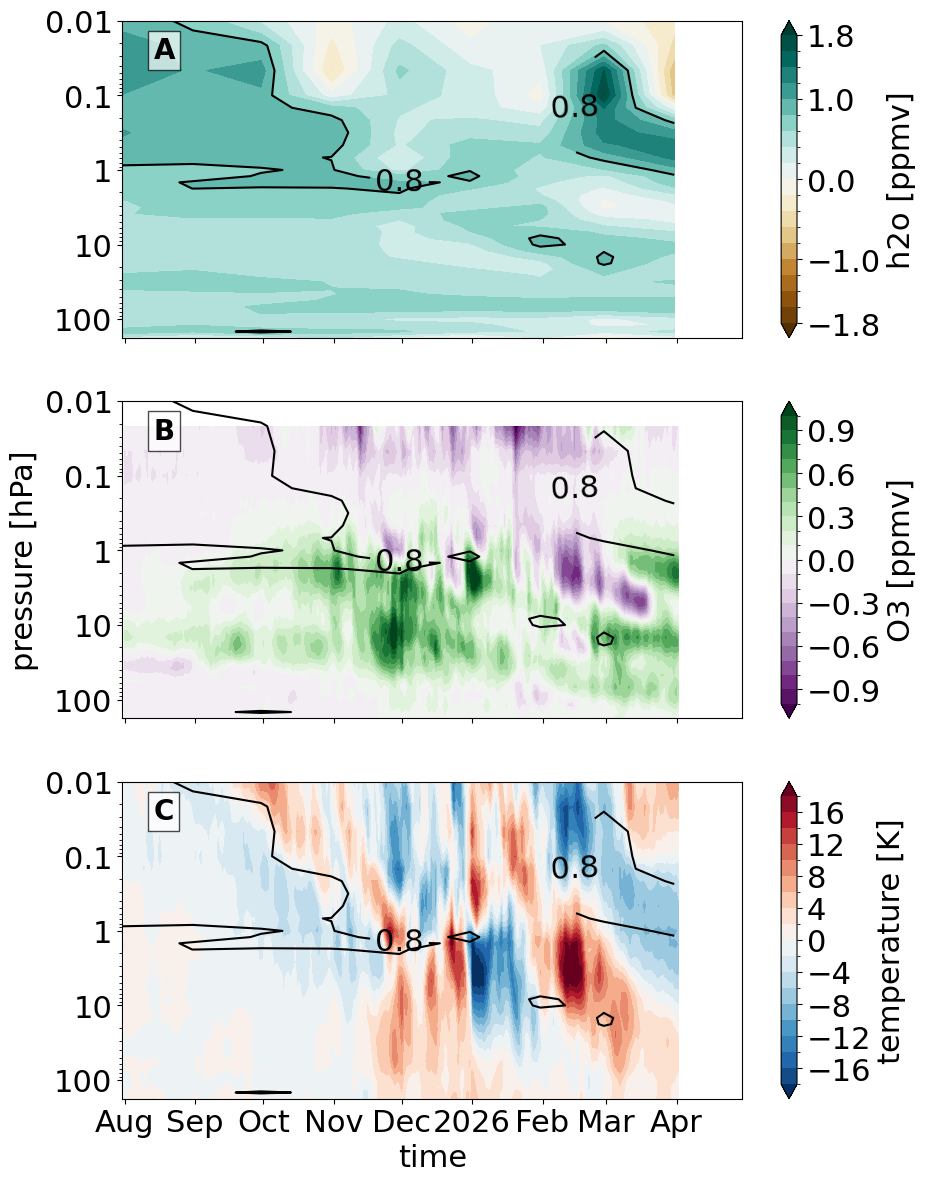

In [45]:
n_rows = 3
f, axes = plt.subplots(n_rows, 1, figsize=(10, 14), sharex =True)
weights = np.cos(np.deg2rad(ds.latitude_bins))
weights.name = "weights"
pres_start=200
pres_end = 0.01
s_year = 2025
e_year = 2026
s_month = 8
e_month = 4
time_start = f'{s_year}-{s_month:02d}'
time_end =  f'{e_year}-{e_month:02d}'

sel_var_ls = ['h2o','O3','temperature',]
cmap_ls = ['BrBG',"PRGn",'RdBu_r',]


temp_dict = {}
for i, (sel_var, ax, cmap) in enumerate(zip(sel_var_ls,axes,cmap_ls)):
   
    if sel_var == 'h2o':
        temp = h2o_anom_int_mon.sel(
            latitude_bins = slice(60,None),
            time = slice(f'{s_year}-{s_month-1:02d}', time_end),
            pressure = slice(pres_start,pres_end),    
        ).weighted(weights).mean('latitude_bins')
        temp = temp.interpolate_na(dim = 'time')
    else:
        temp = anom_int[sel_var].sel(
            latitude_bins = slice(60,None),
            time = slice(time_start, time_end),
            pressure = slice(pres_start,pres_end),    
        ).weighted(weights).mean('latitude_bins')

    temp_dict[sel_var] = temp

    if sel_var == 'O3':
        p = temp.plot.contourf(
            x = 'time', robust = True, cmap = cmap, 
            yincrease = False, extend = 'both', 
            levels = np.arange(-1,1.1,0.1),
            ax = ax
        )
    elif sel_var == 'h2o':
        p = temp.plot.contourf(
            x = 'time', robust = True, cmap = cmap, 
            yincrease = False, extend = 'both', 
            levels = np.arange(-1.8,2,0.2),
            ax = ax, cbar_kwargs = dict(ticks = [-1.8,-1,0,1,1.8])
        )
    else:
        p = temp.plot.contourf(
            x = 'time', robust = True, cmap = cmap, 
            yincrease = False, extend = 'both', 
            levels = np.arange(-18,20,2),
            center = 0,
            ax = ax
        )
    print(sel_var, p.colorbar.vmax)
    if sel_var in ['h2o','temperature','O3']:
        CS = temp_dict['h2o'].plot.contour(
            x = 'time', 
            yincrease = False, add_colorbar = False, 
            levels = [0.8],
            colors = ('k'),
            ax = ax
        )
        ax.clabel(CS)
    
    ax.set_yscale('log')
    fmt = mpl.ticker.FormatStrFormatter("%g")
    ax.yaxis.set_major_formatter(fmt)
    
    if i != n_rows-1:
        ax.set_xlabel('')

    if i != 1:
        ax.set_ylabel('')

    label = ascii_uppercase[i]
    ax.text(
            0.05,
            0.95,
            label,
            transform=ax.transAxes,
            fontsize=20,
            fontweight="bold",
            va="top",
            bbox={"alpha": 0.7, "facecolor": "white"},
        )


outfile = f"TE+WV+O3_time-evolution_{time_start}-{time_end}_MLS{mls_suffix}_anom.pdf"
print(outfile)
#plt.savefig(outfile, bbox_inches="tight")